In [1]:
BasePath = joinpath(homedir(),"jupyter","julia","sivers") 
ModulePath = joinpath(BasePath,"sivers.jl") 
include(ModulePath)
using .Sivers

# Parameters handled separately
ParametersPath = joinpath(BasePath,"parameters.jl")
include(ParametersPath)
using .parameters: params
# # Parameters and SU(Nc) algebra set in parameters.jl
alpha_s = params.alpha_s
Nc = params.Nc
mN = params.mN
mq = params.mq
dabc2 = (Nc^2 - 4) * (Nc^2 - 1) / Nc ;

Check spin sums and wf generation

In [2]:
x = rand(6)
(x1, x2, x3), dx = hp.cuba_to_parton_x(x[1:2])
r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])
r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])

# Reconstruct cartesian momenta from polar coordinates
k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
k3 = - (k1 + k2) 
wf = compute_wavefunction(1,k1,k2,k3,x1,x2,x3);
wf[1,2,1]

2.739751491898426e-13 + 7.317565602956615e-14im

In [13]:
baryon_wavefunction(1, -1, -1 , -1, k1, k2, k3, x1, x2, x3)

2.374305843605269e-13 + 1.5395368975823604e-13im

In [12]:
wf[1,1,1]

2.374305843605269e-13 + 1.5395368975823604e-13im

In [7]:
wf[2,1,2]

3.8940629606222016e-13 + 5.4858492817821074e-14im

In [8]:
for s1 in (-1,1), s2 in (-1,1), s3 in (-1,1)
    i1, i2, i3 = hp.spin_index(s1), hp.spin_index(s2), hp.spin_index(s3)
    println(s1,", ",s2,", ",s3 )
    println(i1,", ",i2,", ",i3 )
end

-1, -1, -1
1, 1, 1
-1, -1, 1
1, 1, 2
-1, 1, -1
1, 2, 1
-1, 1, 1
1, 2, 2
1, -1, -1
2, 1, 1
1, -1, 1
2, 1, 2
1, 1, -1
2, 2, 1
1, 1, 1
2, 2, 2


In [9]:
delta = 1e-4
fdu = f_form_factor(1,-1,[delta,0])
res = delta / 3 / 0.26
println(res/ real(fdu[1]))

delta = 1e-6
fdu = f_form_factor(1,-1,[delta,0])
res = delta / 3 / 0.26
println(res/ real(fdu[1]))

delta = 1e-8
fdu = f_form_factor(1,-1,[delta,0])
res = delta / 3 / 0.26
println(res/ real(fdu[1]))

delta = 1e-10
fdu = f_form_factor(1,-1,[delta,0])
res = delta / 3 / 0.26
println(res/ real(fdu[1]))

delta = 1e-12
fdu = f_form_factor(1,-1,[delta,0])
res = delta / 3 / 0.26
println(res/ real(fdu[1]))

1.3245493045764969
1.324549153102891
1.3245489737070975
1.324537047969256
1.324567524861592


In [3]:
println(f_form_factor(1,1,[0,0]))
println(f_form_factor(-1,-1,[0,0]))

(0.9999999999999997 + 0.0im, [0.0018400710322449996, 8.142188259720008e-23])
(0.9999999999999973 + 0.0im, [0.0018400710322449452, 8.142188259720008e-23])


# Sivers Function

test vanishing of cubic color corellator

In [38]:
function test(s01,s02,x)
    k = [0,0]
    (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
    # Momenta
    r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
    r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
    r3, ϕ3, d2q2 = hp.cuba_to_polar(x[7:8])    # q2
    
    # Reconstruct cartesian momenta from polar coordinates
    k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
    k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
    k3 = - (k1 + k2)  # Enforce transverse momentum conservation
    d4k = d2k1 * d2k2

    q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
    # q2 = [0,0]
    # Jacobian
    d8x = d2x * d4k * d2q2 # 2 + 4 + 2 = 8d integral

    total = complex(0,0)
    for s in (+1,-1)
        # Flip momenta to project out Sivers function
        q1, q2, q3 = s * k, s * q2, - s * (k + q2)
        # k1, k2, k3 = s * k1, s * k2, s * k3  
        ccc = cubic_color_correlator(s01,s02,x1,x2,x3,q1,q2,q3,k1,k2,k3)
        total += s * ccc
    end
    return total
end

# Use this to check cubic color correlator vanishes when:
# - one of the q_i -> 0
# - s01=s02

for i in 1:10000
    x = rand(8)
    tmp = test(1,-1,x)
    if abs(real(tmp)) > 1e-12 || abs(imag(tmp)) > 1e-12
        println(tmp)
    end
end

Same but without using the symmetry

In [42]:
function test_v2(s01,s02,x)
    k = [0,0]
    (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
    # Momenta
    r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
    r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
    r3, ϕ3, d2q2 = hp.cuba_to_polar(x[7:8])    # q2
    
    # Reconstruct cartesian momenta from polar coordinates
    k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
    k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
    k3 = - (k1 + k2)  # Enforce transverse momentum conservation
    d4k = d2k1 * d2k2

    q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
    # q2 = [0,0]
    # Jacobian
    d8x = d2x * d4k * d2q2 # 2 + 4 + 2 = 8d integral

    total = complex(0,0)
    for s in (+1,-1)
        # Flip momenta to project out Sivers function
        q1, q3 = s * k, - s * k - q2
        # k1, k2, k3 = s * k1, s * k2, s * k3  
        ccc = cubic_color_correlator(s01,s02,x1,x2,x3,q1,q2,q3,k1,k2,k3)
        total += s * ccc
    end
    return total
end

# Use this to check cubic color correlator vanishes when:
# - one of the q_i -> 0
# - s01=s02

for i in 1:10000
    x = rand(8)
    tmp = test_v2(1,-1,x)
    if abs(real(tmp)) > 1e-12 || abs(imag(tmp)) > 1e-12
        println(tmp)
    end
end

Try with vegas mc integration

In [33]:
using MCIntegration
function odderon_distribution_mc(  s01::Integer,s02::Integer,
                                k::Vector{<:Real},Δ::Vector{<:Real};
                                mu::Real=0.01,neval=1_000_000)
    if !iszero(Δ)
        throw(ArgumentError("Implementation currently only for vanishing Δ."))
    end

    function integrand(x,c)
        # Transform [0,1]^8 cuba samples to physical variables
        # Parton-x
        (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
        # Momenta
        r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
        r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
        r3, ϕ3, d2q2 = hp.cuba_to_polar(x[7:8])    # q2
        
        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation
        d4k = d2k1 * d2k2

        q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
        # Jacobian
        d8x = d2x * d4k * d2q2 # 2 + 4 + 2 = 8d integral

        total = complex(0,0)
        for s in (+1,-1)
            # Flip momenta to project out Sivers function
            q1, q2, q3 = s * k, s * q2, - s * (k + q2)
            # k1, k2, k3 = s * k1, s * k2, s * k3  
            ccc = cubic_color_correlator(s01,s02,x1,x2,x3,q1,q2,q3,k1,k2,k3)
            total += s * ccc
        end
        # Regenerate initial q2
        q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
        q3 = k + q2
        q22 = sum(q2.^2)
        q32 = sum(q3.^2)
        # Add regulator
        mu2 = mu^2
        q22 += mu2
        q32 += mu2
        # Same denominator
        # for both terms once momenta
        # have been flipped
        den = q22 * q32  
        total *=  d8x / den

        return (real(total), imag(total))
    end
    # integral, err = cuhre(integrand, 8, 2; atol=1e-12, rtol=1e-10);
    var = Continuous(0.0, 1.0)
    result = integrate(integrand; var, dof = [[8,],[8,]], print=-1, solver=:vegas, neval = neval)
    return result
end
println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.00,neval=1_000_0))
println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.01,neval=1_000_0))
println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.01,neval=1_000_00))
println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.01,neval=1_000_000))

# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.02,neval=1_000))
# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.03,neval=1_000))
# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.04,neval=1_000))
# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.05,neval=1_000))

Total iterations * blocks 160: 100%|██████| Time: 0:01:03 ( 0.40  s/it)
Integral 1 = 45.425254617707914 ± 88.12164236033291   (reduced chi2 = 0.862)
Integral 2 = -35.48619284850894 ± 35.010370608645694   (reduced chi2 = 0.873)
Total iterations * blocks 160: 100%|██████| Time: 0:01:03 ( 0.40  s/it)
Integral 1 = 137.71681373327846 ± 70.22016686368532   (reduced chi2 = 1.51)
Integral 2 = 29.13115551209965 ± 16.688717684988205   (reduced chi2 = 0.685)
Total iterations * blocks 160: 100%|██████| Time: 0:10:29 ( 3.94  s/it)
Integral 1 = 143.30484950396087 ± 40.21013818713823   (reduced chi2 = 0.929)
Integral 2 = 10.6815175685241 ± 14.670028051302529   (reduced chi2 = 0.584)
Total iterations * blocks 160: 100%|██████| Time: 1:44:56 (39.35  s/it)
Integral 1 = 123.66695297681754 ± 7.789298093873574   (reduced chi2 = 0.434)
Integral 2 = -0.1660670390388137 ± 3.353828757550017   (reduced chi2 = 2.12)


In [34]:
using MCIntegration
function odderon_distribution_mc_v2(  s01::Integer,s02::Integer,
                                k::Vector{<:Real},Δ::Vector{<:Real};
                                mu::Real=0.01,neval=1_000_000)
    if !iszero(Δ)
        throw(ArgumentError("Implementation currently only for vanishing Δ."))
    end

    function integrand(x,c)
        # Transform [0,1]^8 cuba samples to physical variables
        # Parton-x
        (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
        # Momenta
        r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
        r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
        r3, ϕ3, d2q2 = hp.cuba_to_polar(x[7:8])    # q2
        
        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation
        d4k = d2k1 * d2k2

        q2 = [r3 * cos(ϕ3), r3 * sin(ϕ3)]
        # Jacobian
        d8x = d2x * d4k * d2q2 # 2 + 4 + 2 = 8d integral

        # Add regulator
        mu2 = mu^2

        total = complex(0,0)
        for s in (+1,-1)
            # Flip momenta to project out Sivers function
            q1, q3 = s * k, - s * k - q2
            q32 = sum(q3.^2)
            q32 += mu2
            # k1, k2, k3 = s * k1, s * k2, s * k3  
            ccc = cubic_color_correlator(s01,s02,x1,x2,x3,q1,q2,q3,k1,k2,k3)
            total += s * ccc / q32
        end
        q22 = sum(q2.^2)
        q22 += mu2
        total *=  d8x / q22

        return (real(total), imag(total))
    end
    # integral, err = cuhre(integrand, 8, 2; atol=1e-12, rtol=1e-10);
    var = Continuous(0.0, 1.0)
    result = integrate(integrand; var, dof = [[8,],[8,]], print=-1, solver=:vegas, neval = neval)
    return result
end
println(odderon_distribution_mc_v2(1,-1,[0.1,0],[0,0];mu=0.00,neval=1_000_0))
println(odderon_distribution_mc_v2(1,-1,[0.1,0],[0,0];mu=0.01,neval=1_000_0))
println(odderon_distribution_mc_v2(1,-1,[0.1,0],[0,0];mu=0.01,neval=1_000_00))
# println(odderon_distribution_mc_v2(1,-1,[0.1,0],[0,0];mu=0.01,neval=1_000_000))

# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.02,neval=1_000))
# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.03,neval=1_000))
# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.04,neval=1_000))
# println(odderon_distribution_mc(1,-1,[0.1,0],[0,0];mu=0.05,neval=1_000))

Total iterations * blocks 160: 100%|██████| Time: 0:01:02 ( 0.39  s/it)
Integral 1 = -98.56853022344467 ± 813.0785962446147   (reduced chi2 = 0.582)
Integral 2 = 252.6043387836366 ± 186.22071902846017   (reduced chi2 = 0.651)
Total iterations * blocks 160: 100%|██████| Time: 0:01:02 ( 0.39  s/it)
Integral 1 = -701.3691962765522 ± 1172.2279097084204   (reduced chi2 = 1.41)
Integral 2 = -657.4073195527706 ± 450.9718314418936   (reduced chi2 = 0.744)
Total iterations * blocks 160: 100%|██████| Time: 0:10:23 ( 3.90  s/it)
Integral 1 = -661.7163981714145 ± 741.4405133312276   (reduced chi2 = 1.32)
Integral 2 = -120.6203852132277 ± 159.0242714704169   (reduced chi2 = 1.01)


# Plots of sivers (now done in python)

In [ ]:
function read_csv(filename::String; header::Bool = true)
    open(filename, "r") do io
        lines = readlines(io)
        if header
            lines = Iterators.drop(lines, 1)
        end

        # Parse each line into mixed Float64 / ComplexF64
        rows = [
            [imag(x) == 0 ? real(x) : x for x in parse.(ComplexF64, split(chomp(line), ','))]
            for line in lines
        ]

        # Transpose rows into columns
        ncols = length(rows[1])
        data = [ [row[i] for row in rows] for i in 1:ncols ]

        return data
    end
end


read_csv (generic function with 1 method)

In [ ]:
using Plots
pyplot()

mu_vals = [0.01, 0.02, 0.03, 0.04, 0.05]

# Initialize empty
plt = plot(
    xlabel = "k_perp",
    ylabel = "(126)",
    linewidth = 2,
    gridalpha = 0.2,
    gridlinewidth = 1.5,
);

# Add each series
for (i, mu) in enumerate(mu_vals)
    f_name = "output_" * string(mu) * ".csv"
    k_vals, vals, _, _ = read_csv(f_name)
    # Plot with line
    plot!(plt, k_vals, real.(vals),
        label = "μ = $mu"
    )
end

# display(plt)

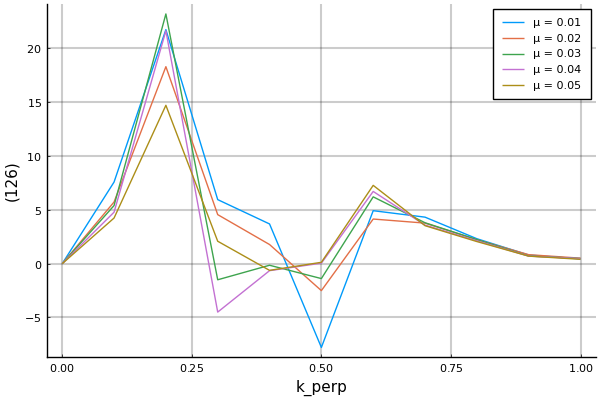

In [ ]:
display(plt)

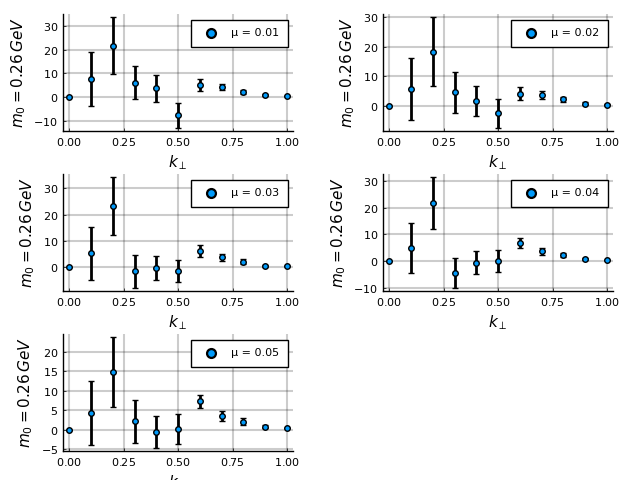

sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.0, 0.0, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.0, 0.0, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.0, 0.0, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.0, 0.0, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.0, 0.0, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in 

Figure(PyObject <Figure size 640x480 with 5 Axes>)

"/home/fhechenberger/jupyter/julia/sivers/odderon_dist_m026_mu_scan_jl.pdf"

In [ ]:
using Plots; using Plots.PlotMeasures; using LaTeXStrings; pyplot();

mu_vals = [0.01, 0.02, 0.03, 0.04, 0.05]

# Prepare a list to hold individual plots
plots_list = []

for mu in mu_vals
    f_name = "output_" * string(mu) * ".csv"
    k_vals, vals, err, _ = read_csv(f_name)
    
    p = plot(
        k_vals, real.(vals),
        yerror = err,
        seriestype = :scatter,
        xlabel = L"k_\perp",
        ylabel = L"m_0=0.26\, GeV",
        linewidth = 2,
        gridalpha = 0.2,
        gridlinewidth = 1.5,
        label = "μ = $mu",
        left_margin = 5mm,
        top_margin = 10mm,
        bottom_margin = 5mm,
        right_margin = 5mm
    )
    
    push!(plots_list, p)
end

# Arrange plots in a 2-column grid
# final_plot = plot(plots_list..., layout = (ceil(Int, length(mu_vals)/2), 2), size=(800, 400*ceil(Int,length(mu_vals)/2)))

nrows = ceil(Int, length(plots_list) / 2)

final_plot = plot(
    plots_list...,
    layout = (nrows, 2),
    size = (950, 450 * nrows),
    layout_padding = (50, 50),
    left_margin = 10mm,
    right_margin = 10mm,
    bottom_margin = 10mm
)
display(final_plot)
savefig(final_plot, "odderon_dist_m026_mu_scan_jl.pdf")

# $F_2$ form factor

In [ ]:
using Cuba
function f_form_factor_(s01::Integer,s02::Integer,Δ::Vector{<:Real})
    eu, ed = 2/3, -1/3
    charges = (eu,eu,ed)
    function integrand(x,f)
        (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
        r1, ϕ1, d2k1 = hp.cuba_to_polar(x[3:4])    # k1
        r2, ϕ2, d2k2 = hp.cuba_to_polar(x[5:6])    # k2
        
        # Reconstruct cartesian momenta from polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation

        # Jacobian
        d4k = d2k1 * d2k2

        total = 0
        wf1 = compute_wavefunction(s01,k1,k2,k3,x1,x2,x3)
        # Sum over charge contributions
        for (i,q) in enumerate(charges)
            k1prime = k1 - x1 * Δ + hp.kronecker_delta(i,1) * Δ
            k2prime = k2 - x2 * Δ + hp.kronecker_delta(i,2) * Δ
            k3prime = k3 - x3 * Δ + hp.kronecker_delta(i,3) * Δ
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum over spin contributions
            total += q * spin_sum(wf1,wf2)
        end
        res = total * d4k * d2x
        f[1] = real(res)
        f[2] = imag(res)
    end
    # Call cuhre with ncomp=2 to track real and imaginary parts separately
    integral, err = cuhre(integrand, 6, 2, atol=1e-12, rtol=1e-10);
    # Reconstruct complex result and
    # multiply with prefactors from integration
    result =  3 / (4π)^2 / (2π)^4 * complex(integral[1],integral[2])
    return result, err
end
f_form_factor_(1,-1,[0.5,0])

(0.2396635812518248 + 1.5595290913267938e-18im, [30.72552385973828, 4.7310390858015685e-14])

In [3]:
Δ_array = 0.01:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f2_form_factor([Δ, 0.0])
end
println(results)

ComplexF64[3.632555020921328 - 3.885451927630072e-17im, 3.4254573092269376 - 3.4010637062010373e-17im, 2.9414978217256973 - 2.1253754133990417e-17im, 2.3363948747402254 - 6.173980144732099e-18im, 1.7555070340779595 - 1.7328428435381266e-17im, 0.48929915489161563 + 6.958660237830215e-18im, 0.34121014210382067 + 4.918631955162941e-18im, 0.5783866067141461 + 2.0660428993814585e-19im, 0.41102308086710704 + 2.645114494181864e-18im, 0.2775684179152119 + 4.06321770208814e-18im, 0.18553975395663375 + 8.142559283946496e-19im, 0.12354780891601125 - 9.534626376741104e-19im, 0.08362718828796885 + 1.0595311060913135e-18im, 0.055450685355050384 - 6.896286925562355e-19im, 0.03719562867385689 - 4.843828773405643e-18im, 0.02410581656442129 + 1.1720820294485139e-18im, 0.015986357068138623 + 7.239501689357285e-19im, 0.010917100060504555 - 6.869169270945079e-19im, 0.007354228567580959 - 1.4045968273527693e-21im, 0.005007953709997874 + 1.4316027778974332e-18im, 0.0033854659630930613 + 1.424933822504677e-18

In [5]:
for i in 1:length(Δ_array)
    Δ, res = Δ_array[i], results[i]
    open("output_f2.csv", "a") do io
        println(io, join([Δ, real(res), imag(res)], ","))
    end
end

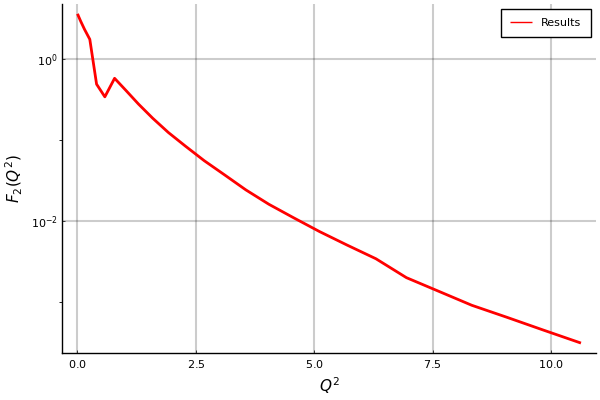

In [8]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real.(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_2(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

In [ ]:
############################################################################
############################################################################
###   ___  _     _       _          __  __   _          _                ###
###  / _ \| | __| |  ___| |_ _   _ / _|/ _| | |__   ___| | _____      __ ###
### | | | | |/ _` | / __| __| | | | |_| |_  | '_ \ / _ \ |/ _ \ \ /\ / / ###
### | |_| | | (_| | \__ \ |_| |_| |  _|  _| | |_) |  __/ | (_) \ V  V /  ###
###  \___/|_|\__,_| |___/\__|\__,_|_| |_|   |_.__/ \___|_|\___/ \_/\_/   ###
###                                                                      ###
############################################################################
############################################################################

<!--  $F_1$ form factor -->

# $F_1$ form factor

In [5]:
Δ_array = 0:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f1_form_factor([Δ, 0.0])
end
println(results)

ComplexF64[0.9999999999999997 + 0.0im, 0.9572091034694046 + 5.6323545605750404e-18im, 0.843494649926187 - 1.8332131107873858e-18im, 0.6950090937754426 + 1.0683542947834576e-20im, 0.53634728673252 - 3.0257921729304074e-18im, 0.41346650949844466 + 7.422198325649891e-19im, 0.30573413559086576 - 2.0544760209593528e-18im, 0.22415183710320147 + 1.901546206958841e-18im, 0.16097664160400804 + 2.2687986568312084e-18im, 0.115306098028049 + 7.109371968675635e-18im, 0.08123573225491336 + 6.337843600278288e-18im, 0.05812431920828342 + 8.753476112530942e-18im, 0.03884774746985036 + 1.9055426264454705e-17im, 0.029623961133729983 + 1.6272708098983888e-17im, 0.021153454630683275 + 2.830653195314111e-17im, 0.014963390847058727 + 4.253636883097329e-17im, 0.010610081123819462 + 4.2555326471838945e-17im, 0.007583093896683425 + 4.281265130554631e-17im, 0.005456515301204452 + 3.679409721751792e-17im, 0.0038801770905851295 + 3.1604895423968004e-17im, 0.0026181560263253394 + 2.36228850211625e-17im, 0.001879586

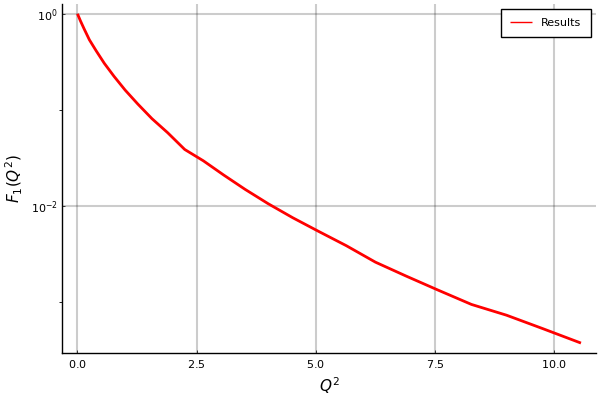

In [6]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_1(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

Proton radius

Linearized result:
  Proton radius R[fm] = 0.8005867626896324
Dipole fit result:
  M_D = 0.5548066716519863
  Proton radius R[fm] = 0.8719690099601666
  Uncertainty: M_D^2 ± 0.00951692175863781, R ± 0.06825227055702685


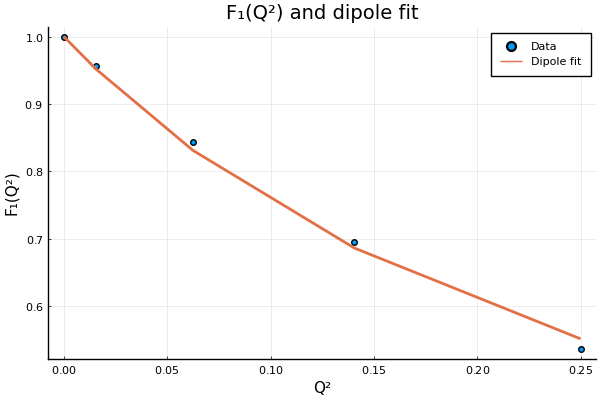

In [9]:
using LsqFit, Plots
Q2_array = Δ_array.^2
F1 = real(results)

# Linearized derivative
println("Linearized result:")
dF_qQ2 = (F1[2] - F1[1]) / (Q2_array[2] - Q2_array[1])
R = sqrt(-6 * dF_qQ2) 

hbarc = 0.1975
println("  Proton radius R[fm] = ", R * hbarc)

# Restrict to Q^2 ≤ Qmax2
Qmax2 = 0.28
mask = Q2_array .<= Qmax2
x = Q2_array[mask]
y = F1[mask]

# Dipole model: p[1] = M_D^2
# model(x,p) = 1.0 ./ (1 .+ x ./ p[1])
# More elegant way to write
@. model(x,p) = 1.0 / (1 + x / p[1])

# Initial guess for M_D^2 (~0.71 GeV^2 for proton)
p0 = [0.7]

fit = curve_fit(model, x, y, p0)

MD2 = fit.param[1]
R = sqrt(6 / MD2) 

println("Dipole fit result:")
println("  M_D = ", sqrt(MD2))
println("  Proton radius R[fm] = ", R * hbarc)

# Error estimate
cov = estimate_covar(fit)
σ_MD2 = sqrt(cov[1,1])
σ_R = 0.5 * sqrt(6) * σ_MD2 / (MD2^(3/2))
println("  Uncertainty: M_D^2 ± ", σ_MD2, ", R ± ", σ_R)

F1_fit = model(x, fit.param)

plot(x, y, seriestype=:scatter, label="Data", xlabel="Q²", ylabel="F₁(Q²)",
     title="F₁(Q²) and dipole fit", legend=:topright)
plot!(x, F1_fit, label="Dipole fit", lw=2)


# Benchmark tests

Things I have tried to speed up:
- Summation outside integrand and summing contributions obtained by cuhre slightly faster
- Summation inside integrand is slightly slower
- Parallelizing with CUBACORES actually takes longer
- No speed up with parallelization in general

In [ ]:
using Cuba
using BenchmarkTools
"""
    cuba_to_polar(x)

Transform a Cuba sample `x ∈ [0,1]^2` into polar coordinates.

# Arguments
- `x::Vector{<:Real}`: Sample point in the unit circle `[0,1]^2`.

# Returns
- `r::Real`: Radius
- `ϕ::Real`: Azimuthal angle
- `jac::Real`: Jacobian determinant of the transformation

# Notes
Throws an `ArgumentError` if called with `length(x) != 2`.
"""
function cuba_to_polar(x::Vector{<:Real})
    n = length(x)            
    if n != 2
        throw(ArgumentError("Input must be two-dimensional for polar coordinates"))
    end
    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2
    ϕ = 2π * x[2]
    jac = 2π * r * drdx

    return r, ϕ, jac
end

function cuba_to_hyperspherical(x::Vector{<:Real})
    n = length(x)            
    if n < 2
        throw(ArgumentError("Need at least 2 dimensions for hyperspherical coordinates"))
    end

    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2

    thetas = zeros(eltype(x), n-1)

    jac = r^(n-1) * drdx

    # first n-2 angles in [0, π]
    for i in 1:(n-2)
        cosθ = 2*x[i+1] - 1
        θ = acos(cosθ)
        thetas[i] = θ
        jac *= 2 * sin(θ)^(n-i-2)
    end

    # last angle in [0,2π)
    ϕ = 2π * x[n]
    thetas[end] = ϕ
    jac *= 2π

    return r, thetas, jac
end

function integrand(x,f)
    r1, ϕ1, d2k1 = cuba_to_polar(x)
    f[1] = exp(-r1^2) * d2k1
end
@btime integral, err = cuhre(integrand,2,1)
println(integral[1])

function integrand(x,f)
    r1, (ϕ1,), d2k1 = cuba_to_hyperspherical(x)
    f[1] = exp(-r1^2) * d2k1
end

@btime integral, err = cuhre(integrand,2,1)
println(integral[1])


  46.419 μs (2343 allocations: 73.31 KiB)
3.141592697100627
  59.469 μs (2928 allocations: 109.88 KiB)
3.141592697100627
